# Download, extract, & prep mcool files

In [ ]:
%%bash

cd ~/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K

filenames=$(for each in Oligo_NN L6_CT_CTX_Glut Astro-TE_NN L2_3_IT_CTX_Glut Endo_NN L4_5_IT_CTX_Glut L5_IT_CTX_Glut L6_IT_CTX_Glut; do ls $each*; done)

mkdir originals
mv *.mcool originals/
mkdir selected && cd selected


for each in $filenames; do
	echo -e "\n======== $each"
	cooler cp ../originals/$each::/resolutions/100000 $each::/resolutions/100000 && cooler ls $each
done


for each in $(ls *.mcool); do
	echo -e "\n\n======== $each"
	cooler coarsen -k 25 $each::/resolutions/100000 -o $each::/resolutions/2500000 -a && echo && cooler ls $each
    cooler coarsen -k 5 $each::/resolutions/100000 -o $each::/resolutions/500000 -a && echo && cooler ls $each
done


for each in $(ls *.mcool); do
	echo -e "\n======== $each"
	cooler balance $each::/resolutions/2500000 --cis-only --convergence-policy 'discard' 
    cooler balance $each::/resolutions/500000 --cis-only --convergence-policy 'discard' 
done


# for each in $filenames; do
# 	echo -e "\n$each"
# 	cooler ls $each
# done


# Distance decay - mcool files

In [ ]:
%load_ext autoreload
%autoreload 2 

In [ ]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations
import os

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
from multiprocessing import Pool

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorial relies on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# count cpus
num_cpus = os.getenv('SLURM_CPUS_PER_TASK')
if not num_cpus:
    num_cpus = os.cpu_count()
num_cpus = int(num_cpus)

In [ ]:
# resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
resolution = int(1000 * 500) # 500 kb (5e5 bp)

In [ ]:
# get centromere data from ucsc gap file
mm10_gap = pd.read_csv(
    '/net/gs/vol1/home/gesine/noble_lab/resources/genomic/gaps/ucsc.mm10.gap.txt',
    sep='\t', header=None, names=(
        'bin', 'chrom', 'start', 'end', 'ix', 'n', 'size', 'type', 'bridge'))
mm10_cens = mm10_gap.loc[mm10_gap.type == 'centromere', ['chrom', 'start', 'end']].copy().reset_index()
mm10_cens['mid'] = ((mm10_cens.start + mm10_cens.end) / 2).astype(int)
# Use bioframe to fetch the genomic features from the UCSC.
mm10_chromsizes = bioframe.fetch_chromsizes('mm10')
# create a view with chromosome arms using chromosome sizes and definition of centromeres
mm10_arms = bioframe.make_chromarms(mm10_chromsizes,  mm10_cens)
# remove chrX, chrY, chrM
mm10_arms = mm10_arms[~mm10_arms.chrom.isin(['chrX', 'chrY', 'chrM'])].reset_index(drop=True)
# remove arms that are less than the current binsize/resolution
mm10_arms = mm10_arms[(mm10_arms.end - mm10_arms.start) > resolution]

In [ ]:
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'

uri = f'{mcool_file}::/resolutions/{resolution:d}'

print(uri)
clr = cooler.Cooler(uri)

cis_cov, tot_cov = cooltools.coverage(clr, ignore_diags=1, nproc=2)
print(f"nreads: {cis_cov.sum():,}", flush=True)

In [ ]:
cvd_smooth_agg = cooltools.expected_cis(
    clr=clr,
    view_df= mm10_arms[mm10_arms.chrom.isin(clr.chromnames)].reset_index(drop=True),
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=num_cpus,
    ignore_diags=1, # GC: Given very coarse bin size, only ignore main diagonal
    intra_only=True,  # GC: snm3C-seq data only contains intra-chrom counts
    #clr_weight_name=None,
)

# Compare matrices

## Load

In [502]:
import pandas as pd
import glob
import os
import ast
import numpy as np
import re
from functools import partial

import cooler

import matplotlib.pyplot as plt
from matplotlib import colors
plt.style.use('seaborn-v0_8-paper')
%matplotlib inline
import seaborn as sns
sns.set_theme('paper', style='white')

from topsy.analysis.compare_distances import make_matrix_df

In [ ]:
dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'


sc_dis_intramol_file = glob.glob(os.path.join(dir_matrix2d, '*.distances.intramol.tsv.gz'))
if len(sc_dis_intramol_file) != 1:
    raise ValueError("Couldn't find unique file for intra-mol single cell distances")
sc_dis_intramol_file = sc_dis_intramol_file[0]

sc_dis = sc_dis_intramol = pd.read_csv(
    sc_dis_intramol_file, sep='\t', header=None, index_col=0,
    converters={0: ast.literal_eval})
sc_dis.index.name = None

In [206]:
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'

resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
# resolution = int(1000 * 500) # 500 kb (5e5 bp)

uri = f'{mcool_file}::/resolutions/{resolution:d}'
clr = cooler.Cooler(uri)
snm3c = np.triu(clr.matrix(balance=True if 'Raw.' in mcool_file else False)[:, :], 1)

clr_bins = clr.bins()[:].reset_index().rename({'index': 'idx_clr'}, axis=1)
clr_bins['mid'] = clr_bins[['start', 'end']].mean(axis=1).round().astype(int)
assert len(clr_bins) == snm3c.shape[0]
print(snm3c.shape)

nbins_clr = clr_bins.groupby('chrom', observed=True).size().sort_values(
    ascending=False).drop('chrX')
lengths_clr = clr_bins.groupby('chrom', observed=True).apply(
    lambda x: int(round(x.end.max() / resolution)), include_groups=False).drop('chrX')
assert (np.round((clr.chromsizes / resolution)).drop('chrX') - lengths_clr == 0).all()

(1063, 1063)


In [ ]:
# because I truncated the molecules of the MERFISH data...
lengths_file = '/net/gs/vol1/home/gesine/noble_lab/projects/2015_gesine_diploid/data/liu2025/unambig/astro.nreads1e9.sc_alpha-2/counts.bed'

lengths_df = pd.read_csv(lengths_file, sep='\t')
lengths_df.columns = [c.strip('#') for c in lengths_df.columns]
for col in ['start', 'end', 'mid']:  # Round to nearest 10,000bp
    lengths_df[col] = lengths_df[col].round(-4)

n = len(lengths_df)
lengths_s = lengths_df.groupby('chrom').size().sort_values(
    ascending=False)

lengths_compare = pd.concat([lengths_s.to_frame().rename({0: 'merfish'}, axis=1), lengths_clr.to_frame().rename({0: 'snm3c'}, axis=1)], axis=1)
lengths_compare['difference'] = lengths_compare.snm3c - lengths_compare.merfish
assert (lengths_compare.difference >= 0).all()

lengths_df = lengths_df.merge(clr_bins[['chrom', 'mid', 'idx_clr']], on=['chrom', 'mid'], how='left')
print(f"{lengths_df.idx_clr.isnull().sum()} genomic bins are present in MERFISH but not snm3c")
lengths_df.index = lengths_df.idx_genome
lengths_df.index.name = None
# display(lengths_df.head())

matrix_df = make_matrix_df(lengths_df) #, distance_dict={'idx_clr': lengths_df.idx_clr})
matrix_df = matrix_df[matrix_df['mask.sameC-sameH'] | matrix_df['mask.sameC-diffH']].drop(
    ['mask.sameC-sameH', 'mask.sameC-diffH', 'mask.diffC-sameH', 'mask.diffC-diffH', 'j.chrom'], axis=1).rename(
    {'i.chrom': 'chrom'}, axis=1)
matrix_df['i.idx_clr'] = lengths_df.loc[matrix_df['i.idx_ambig'], 'idx_clr'].values.ravel()
matrix_df['j.idx_clr'] = lengths_df.loc[matrix_df['j.idx_ambig'], 'idx_clr'].values

mask = matrix_df['i.idx_clr'].notnull() & matrix_df['j.idx_clr'].notnull()
matrix_df.loc[mask, 'snm3c'] = snm3c[matrix_df.loc[mask, 'i.idx_clr'].astype(int), matrix_df.loc[mask, 'j.idx_clr'].astype(int)]
matrix_df = matrix_df.loc[matrix_df.index.isin(sc_dis.index)]

## Compare

In [335]:
results = []
if os.path.exists('pseudocounts_vs_snm3c.tsv'):
    results_df = pd.read_csv('pseudocounts_vs_snm3c.tsv', sep='\t')
    results = results_df.to_dict(orient='records')

### Logistic

,func,func_kwargs,mean,med
BEST,logistic,"k=-25, v=2, x0=0.4",0.795123,0.66864


,func,func_kwargs,mean,med
0,logistic,"k=-25, v=2, x0=0.4",0.795123,0.66864



FINAL:


,func,func_kwargs,mean,med
0,logistic,"k=-25, v=2, x0=0.4",0.795123,0.668640
1,logistic,"k=-35, v=3, x0=0.4",0.795006,0.697630
2,logistic,"k=-45, v=4, x0=0.4",0.794885,0.711934
3,logistic,"k=-50, v=4, x0=0.4",0.794845,0.668559
4,logistic,"k=-40, v=3, x0=0.4",0.794814,0.639160


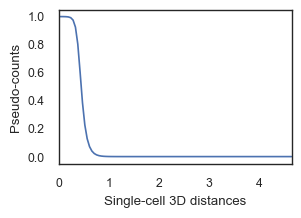

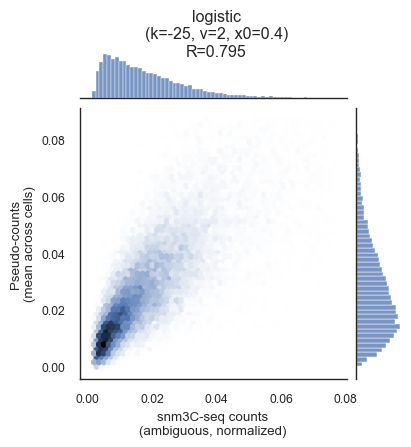

In [511]:
display(results_df.head(1).rename({0: f"BEST"}))
print()

for k in [-25]:
    for v in [2]:
        for x0 in [0.35, 0.45]:
            results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, v=v, x0=x0))[0])
    results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
    results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t')
    display(results_df[results_df.func_kwargs.str.contains(f'{k=},')].head(1))

results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t')
print('\nFINAL:')
display(results_df.head())

plot_best_func(results_df, sc_dis)
plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df)

### Threshold power func

In [539]:
# TODO Test this... with upper/lower cutoff, like for dist decay below !!!!

### Thresholded func

,func,func_kwargs,mean,med
THRESH: BEST,thresholded,cutoff=0.5,0.739005,NaN


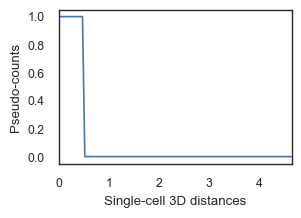

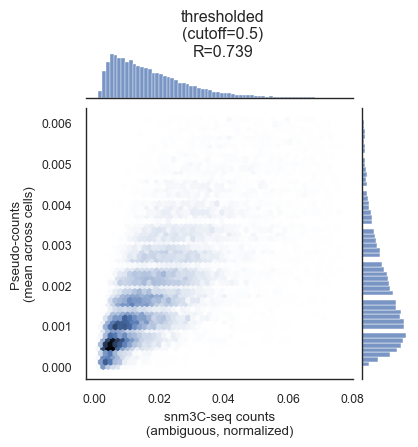

In [538]:
# results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=thresholded, transfer_func_kwargs=dict(cutoff=0.5), plot=False)[0])
# results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
# results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t')

results_df_thr = results_df[results_df.func == 'thresholded'].reset_index(drop=True)
display(results_df_thr.head(1).rename({0: f"THRESH: BEST"}))
plot_best_func(results_df_thr, sc_dis=sc_dis)
plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df_thr)

### Power func

,func,func_kwargs,mean,med
POWER: BEST,power,alpha=-1.3,0.747628,0.756555


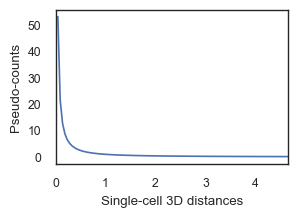

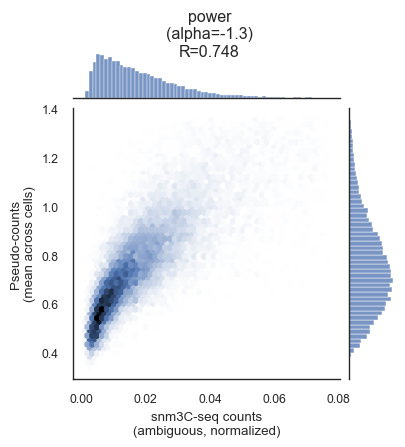

In [537]:
# results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=power, transfer_func_kwargs=dict(alpha=-1.3), plot=False)[0])
# results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
# results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t')

results_df_power = results_df[results_df.func == 'power'].reset_index(drop=True)
display(results_df_power.head(1).rename({0: f"POWER: BEST"}))
plot_best_func(results_df_power, sc_dis=sc_dis)
plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df_power)

## Fxn

In [536]:
def logistic(x, k, x0=0, L=1, v=1):
    assert k < 0
    tmp = -k * (x - x0)
    res = L / np.power(1 + np.exp(tmp), 1 / v)
    # res = np.exp(np.log(L) - np.log1p(np.exp(tmp))) / v
    return res

def power(x, alpha):
    if isinstance(x, np.ndarray):
        y = np.full_like(x, np.nan)
        mask = (~np.isnan(x)) & (x > 0)
        y[mask] = np.power(x[mask], alpha)
        return y
    else:
        return x.pow(alpha)

def thresholded(x, cutoff):
    return x <= cutoff

In [496]:
def assess_pseudocounts(matrix_df, sc_dis, transfer_func, transfer_func_kwargs=None,
                        plot=False, perc_cutoff=0.95, agg_func='mean', verbose=False):
    if transfer_func_kwargs is None:
        transfer_func_kwargs = {}
    counts_sc = transfer_func(sc_dis, **transfer_func_kwargs)
    counts = pd.concat([
        counts_sc.mean(axis=1).to_frame().rename({0: 'pc_mean'}, axis=1),
        counts_sc.median(axis=1).to_frame().rename({0: 'pc_med'}, axis=1)], axis=1)
    matrix_df = matrix_df.join(counts)

    grp_cols = ['i.idx_ambig', 'j.idx_ambig', 'chrom', 'i.idx_chrom', 'j.idx_chrom',
                'genomic_dis', 'mask.nghbr', 'i.idx_clr', 'j.idx_clr']
    matrix_df_ambig = matrix_df[matrix_df.columns[~matrix_df.columns.isin(
        ['i.idx', 'j.idx', 'i.hmlg', 'j.hmlg', 'mask.diffM'])]].groupby(
        grp_cols).mean().reset_index(
        level=np.arange(len(grp_cols)).tolist())

    pearson_r = {
        'func': transfer_func.__name__,
        'func_kwargs': re.sub(r"['{}]", '', transfer_func_kwargs.__str__()).replace(": ", "="),
        'mean': float(matrix_df_ambig[["snm3c", "pc_mean"]].corr(method='pearson').values[0, 1]),
        'med': float(matrix_df_ambig[["snm3c", "pc_med"]].corr(method='pearson').values[0, 1])}
    if verbose:
        print(f"Pearson R:  mean={pearson_r['mean']:.3g}\n             med={pearson_r['med']:.3g}", flush=True)

    if plot:
        plot_counts_corr(matrix_df_ambig, pearson_r=pearson_r, perc_cutoff=perc_cutoff, agg_func=agg_func)

    return pearson_r, (matrix_df, matrix_df_ambig)


def plot_counts_corr(matrix_df_ambig, perc_cutoff=0.95, agg_func='mean', pearson_r=None, title=None):
    xmax = matrix_df_ambig.snm3c.quantile(perc_cutoff)
    ymax = matrix_df_ambig[f"pc_{agg_func}"].quantile(perc_cutoff)
    
    g = sns.jointplot(
        data=matrix_df_ambig[(matrix_df_ambig.snm3c <= xmax) & (matrix_df_ambig[f"pc_{agg_func}"] <= ymax)],
        x="snm3c", y=f"pc_{agg_func}", kind='hex', height=4)
    plt.ylabel(f"Pseudo-counts\n({agg_func} across cells)")
    plt.xlabel(f"snm3C-seq counts\n(ambiguous, normalized)")
    if pearson_r is not None:
        if title is None:
            title = f"{pearson_r['func']}\n({pearson_r['func_kwargs']})"
        title = f"{title}\nR={pearson_r[agg_func]:.3g}"
    if title is not None:
        g.fig.suptitle(title, y=1.07)
    plt.show()

In [513]:
def get_best_func(results_df):
    func_dict = {'logistic': logistic, 'power': power, 'thresholded': thresholded}
    func = func_dict[results_df.loc[0, 'func']]
    func_kwargs = ast.literal_eval("{'" + results_df.loc[0, 'func_kwargs'].replace(
        '=', "': ").replace(', ', ", '") + "}")
    return func, func_kwargs


def plot_best_result(matrix_df, sc_dis, results_df):
    func, func_kwargs = get_best_func(results_df)
    pearson_r, (matrix_df, matrix_df_ambig) = assess_pseudocounts(matrix_df, sc_dis, transfer_func=func, transfer_func_kwargs=func_kwargs, plot=True)


def plot_best_func(results_df, sc_dis):
    func, func_kwargs = get_best_func(results_df)
    
    xmax = np.quantile(sc_dis.values[~np.isnan(sc_dis.values)], 0.99)
    x = np.linspace(0, xmax, num=100)
    y = func(x, **func_kwargs)
    
    fig = plt.figure()
    plt.plot(x, y)
    plt.xlim(0, xmax)
    fig.set_size_inches((3, 2))
    # plt.title(results_df.loc[0, 'func'] + '\n' + results_df.loc[0, 'func_kwargs'])
    plt.xlabel('Single-cell 3D distances')
    plt.ylabel('Pseudo-counts')
    plt.show()

# Idk

## Load

In [1]:
import pandas as pd
import glob
import os
import ast
import numpy as np
from cooltools.sandbox.expected_smoothing import log_smooth

import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import seaborn as sns


dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'


sc_dis_intramol_file = glob.glob(os.path.join(dir_matrix2d, '*.distances.intramol.tsv.gz'))
if len(sc_dis_intramol_file) != 1:
    raise ValueError("Couldn't find unique file for intra-mol single cell distances")
sc_dis_intramol_file = sc_dis_intramol_file[0]

sc_dis_intramol = pd.read_csv(
    sc_dis_intramol_file, sep='\t', header=None, index_col=0,
    converters={0: ast.literal_eval})

## Pseudo-counts

### Hist

In [44]:
tmp = sc_dis_intramol.values.ravel()
tmp = tmp[~np.isnan(tmp)]
print((pd.Series(tmp.round().astype(int)).value_counts() / tmp.size * 100).to_string(float_format=lambda x: f"{x:.2g}%"))

1        42%
2        36%
3        13%
0       3.8%
4       3.6%
5      0.92%
6      0.24%
7     0.056%
8     0.013%
9    0.0029%
10   0.0013%
11   0.0005%


In [77]:
print(pd.Series(tmp[tmp < np.quantile(tmp, 1)]).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\n" + pd.Series(tmp[tmp >= 0.01]).describe().to_string(float_format=lambda x: f"{x:.2g}"))

count   9.4e+06
mean        1.8
std        0.93
min      0.0084
25%         1.1
50%         1.6
75%         2.2
max          11

count   9.4e+06
mean        1.8
std        0.93
min        0.01
25%         1.1
50%         1.6
75%         2.2
max          11


In [ ]:
tmp[tmp < np.quantile(tmp, 0.0001)]

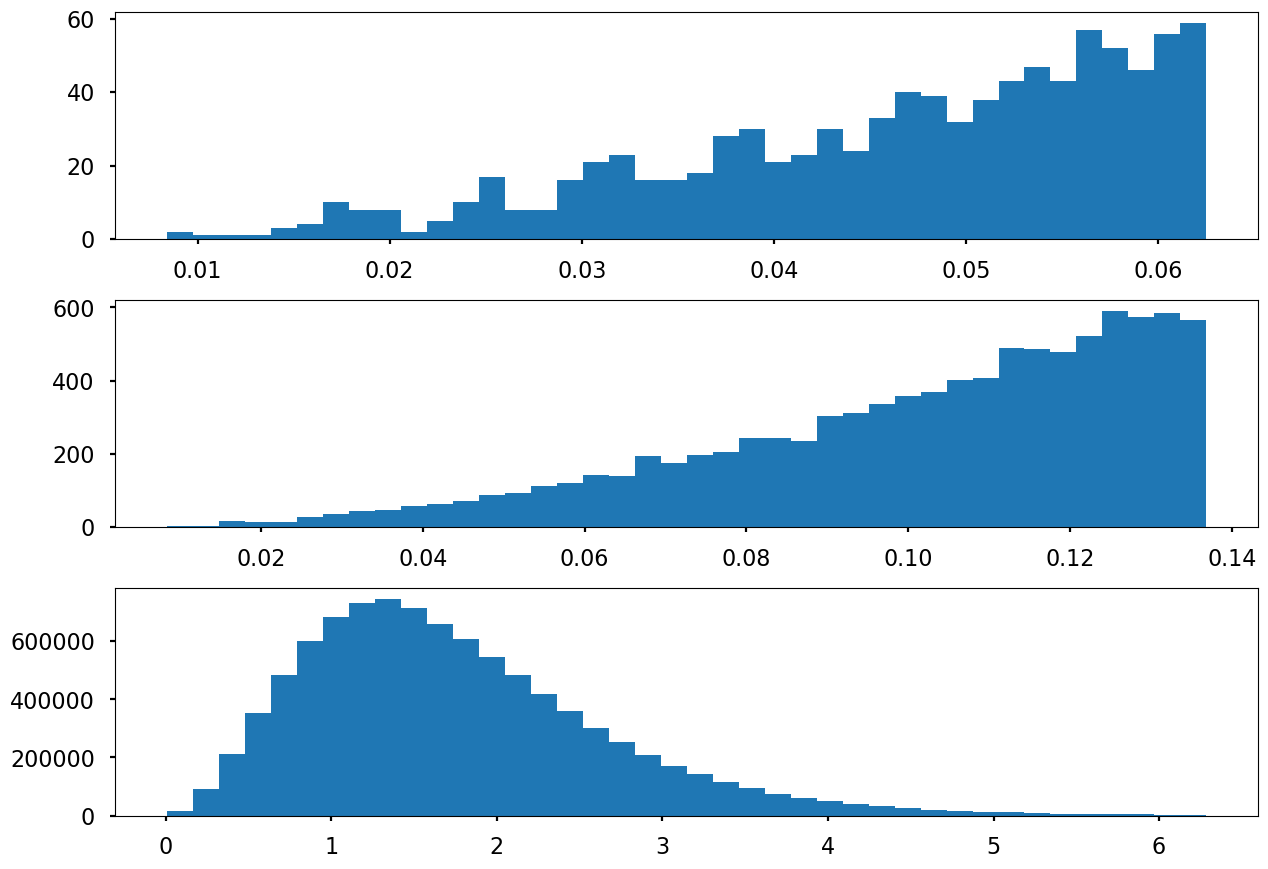

In [73]:
fig, ax = plt.subplots(3, 1, sharey=False, tight_layout=True)

ax[0].hist(tmp[tmp < np.quantile(tmp, 0.0001)], bins=40)
ax[1].hist(tmp[tmp < np.quantile(tmp, 0.001)], bins=40)
ax[2].hist(tmp[tmp < np.quantile(tmp, 0.999)], bins=40)

plt.show()

In [11]:
# PASTIS transfer function ONLY

alpha = -4

sc_counts = sc_dis_intramol.pow(alpha)
sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell distances:\n" + pd.Series(sc_dis_intramol.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nSingle-cell counts:\n" + sc_counts_series.describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

Single-cell distances:
count   9.4e+06
mean        1.8
std        0.93
min      0.0084
25%         1.1
50%         1.6
75%         2.2
max          11

Single-cell counts:
count   9.4e+06
mean    1.5e+02
std     9.1e+04
min       6e-05
25%       0.039
50%        0.16
75%        0.72
max       2e+08

Consensus counts:
count   4.5e+04
mean    1.4e+02
std     5.3e+03
min       0.058
25%         1.7
50%         4.3
75%          13
max       7e+05


In [ ]:
# sns.histplot(data=pd.Series(counts.values.ravel()).to_frame(), x=r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
# sns.histplot(data=counts, x=r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
sns.histplot(data=counts.values)
plt.x_axis(r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
plt.show()

In [9]:
# PASTIS transfer function + 0.75um cutoff
alpha = -4

sc_counts = sc_dis_intramol.pow(alpha)
sc_counts[sc_dis_intramol.notnull() & (sc_dis_intramol > 0.75)] = 0
# sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell counts:\n" + pd.Series(sc_counts.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

sc_counts_series = None
counts.isnull().sum(), (counts == 0).sum()

Single-cell counts:
count   9.4e+06
mean    1.5e+02
std     9.1e+04
min           0
25%           0
50%           0
75%           0
max       2e+08

Consensus counts:
count   4.5e+04
mean    1.4e+02
std     5.3e+03
min           0
25%         1.4
50%           4
75%          13
max       7e+05


In [12]:
# 0.75um cutoff only

sc_counts = pd.DataFrame(0, index=sc_dis_intramol.index, columns=sc_dis_intramol.columns)
sc_counts[sc_dis_intramol.notnull() & (sc_dis_intramol <= 0.75)] = 1
# sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell counts:\n" + pd.Series(sc_counts.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

sc_counts_series = None
counts.isnull().sum(), (counts == 0).sum()

Single-cell counts:
count   1.7e+08
mean     0.0061
std       0.078
min           0
25%           0
50%           0
75%           0
max           1

Consensus counts:
count   4.5e+04
mean     0.0061
std       0.005
min           0
25%      0.0027
50%      0.0049
75%      0.0078
max       0.052


(np.int64(0), np.int64(103))

### Dist decay - pseudo-counts

In [ ]:
# XXX shouldn't the distance decay be for ambiguated counts? not that it'll make a huge difference...

#### c ~ d^alpha

v = 0.785
1/v = 1.27
est alpha = B/v = -1.02


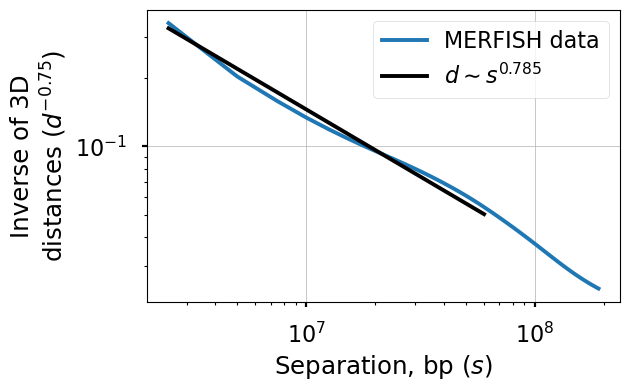

In [151]:
sigma_log10 = 0.1; min_n = None
# dis_exp = -4; min_distance = 0.1; max_distance = 0.75 # 0.162
# dis_exp = -4; min_distance = 0.1; max_distance = 1 # 0.161
# dis_exp = -4; min_distance = 0.1; max_distance = 0.5 # 0.164
# dis_exp = -4; min_distance = 0.01; max_distance = 0.5 # 0.151, noisy
# dis_exp = -4; min_distance = 0.05; max_distance = 0.5 # 0.167
# dis_exp = -4; min_distance = 0.025; max_distance = 0.5 # 0.177
# dis_exp = -3; min_distance = 0.025; max_distance = 0.5 # 0.223
# dis_exp = -3; min_distance = 0.025; max_distance = 0.2 # 0.231
# dis_exp = -2; min_distance = 0.025; max_distance = 0.5 # 0.312
# dis_exp = -2; min_distance = 0.025; max_distance = 0.2 # 0.339 ++
# dis_exp = -2; min_distance = 0.025; max_distance = 0.1 # 0.346, noisier than max_dist=0.2
# dis_exp = -2; min_distance = 0.015; max_distance = 0.2 # 0.335
# dis_exp = -2; min_distance = 0.05; max_distance = 0.2 # 0.335
# dis_exp = -2; min_distance = 0.02; max_distance = 0.2 # 0.337

# dis_exp = -1; min_distance = 0.025; max_distance = 0.5 # 0.593
# dis_exp = -1; min_distance = 0.025; max_distance = 0.2 # 0.666 ++
# dis_exp = -0.75; min_distance = 0.025; max_distance = 0.2 # 0.886 ++
# dis_exp = -0.75; min_distance = 0.025; max_distance = None # 0.201 ++
dis_exp = -0.75; min_distance = None; max_distance = 0.2 # 0.886 ++
# dis_exp = -0.75; min_distance = None; max_distance = 0.5 # 0.785 ++
# dis_exp = -0.5; min_distance = 0.025; max_distance = 0.5 # 1.17
# dis_exp = -0.2; min_distance = 0.025; max_distance = 0.5 # 2.89
# dis_exp = -1; min_distance = None; max_distance = None  # 0.204 ++
# dis_exp = -0.2; min_distance = None; max_distance = None  # 0.196 ++
# dis_exp = -0.75; min_distance = None; max_distance = None  # 0.201 ++
# dis_exp = -1.5; min_distance = None; max_distance = None  # 0.209 ++
# dis_exp = -2; min_distance = None; max_distance = None  # 0.214 ++
# dis_exp = -2.5; min_distance = None; max_distance = None  # 0.214 ++
# dis_exp = -3; min_distance = None; max_distance = None  # 0.201 ++


counts_sc = sc_dis_intramol.pow(dis_exp)
if min_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol < min_distance)] = np.power(min_distance, dis_exp)
if max_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol > max_distance)] = 0
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_genomic_dist_by_cell(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

#### c = std logistic of x=-ln(d)

v = 0.661
1/v = 1.51
est alpha = B/v = -1.21


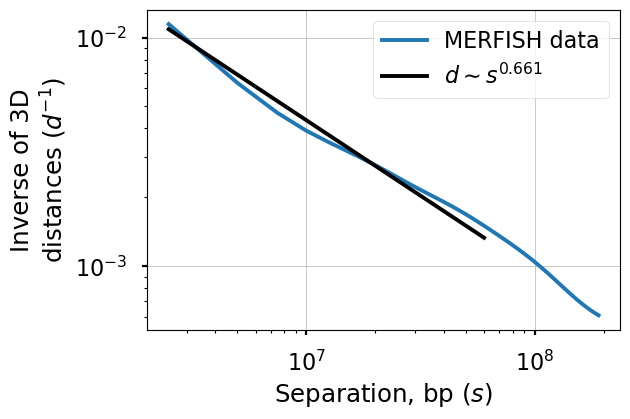

In [65]:
sigma_log10 = 0.1; min_n = None
# dis_exp = -4; min_distance = None; max_distance = None # 0.0853
# dis_exp = -4; min_distance = 0.01; max_distance = 0.75 # noise
# dis_exp = -3; min_distance = None; max_distance = None # 0.0913
# dis_exp = -2; min_distance = None; max_distance = None # 0.0974
# dis_exp = -1; min_distance = None; max_distance = None # 0.103
# dis_exp = -0.5; min_distance = None; max_distance = None # 0.106
# dis_exp = -0.25; min_distance = None; max_distance = None # 0.107

# dis_exp = -4; min_distance = None; max_distance = 0.75 # 0.131
# dis_exp = -4; min_distance = None; max_distance = 0.5 # 0.148
# dis_exp = -4; min_distance = None; max_distance = 0.2 # 0.166
# dis_exp = -3; min_distance = None; max_distance = 0.2 # 0.221
# dis_exp = -1; min_distance = None; max_distance = 0.75 # 0.494
# dis_exp = -1; min_distance = None; max_distance = 0.5 # 0.579
dis_exp = -1; min_distance = None; max_distance = 0.2 # 0.661

counts_sc = (1 + sc_dis_intramol).pow(dis_exp)  # power law where x=d+1 OR logistic fxn of x where x = -ln(d)
# alternative (1 + e^(10*(d-0.5)))^-1) = based on logistic fxn of x where x = -d (equiv to "1 - [logistic fxn of d]")
if min_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol < min_distance)] = np.power(min_distance, dis_exp)
if max_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol > max_distance)] = 0
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_genomic_dist_by_cell(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

#### c = logistic of x=

v = 0.681
1/v = 1.47
est alpha = B/v = -1.18


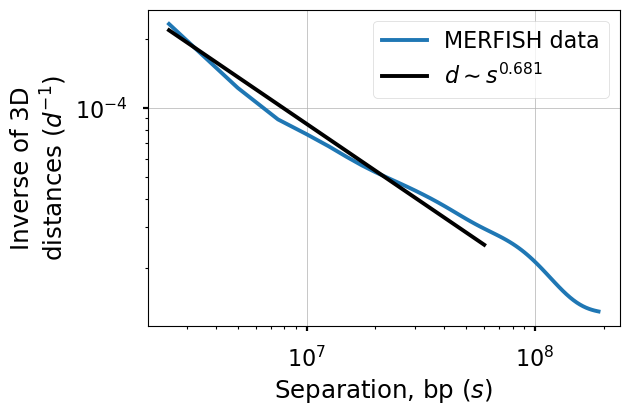

In [140]:
sigma_log10 = 0.1; min_n = None
L = 1
# k = -3;   x0=-0.5  # 0.412
# k = -10;   x0=-0.2  # 0.61
# k = -10;   x0=-0.1  # 0.608
# k = -15;   x0=-0.1  # 0.643
# k = -15;   x0=0     # 0.641
# k = -20;   x0=0     # 0.659
# k = -30;   x0=0     # 0.659
# k = -35;   x0=0     # 0.68
# k = -37;   x0=0     # 0.69
# k = -38;   x0=0     # 0.683
k = -39;   x0=+0.01     # 0.681
# k = -10;   x0=-0.5  # ??



def logistic(x, x0, k, L=1, v=1):
    # x0 <= 0 and k<0
    tmp = -k * (x - x0)
    # try1 = L / np.power(1 + np.exp(-k * (x - x0)), 1 / v)
    try2 = np.exp(np.log(L) - np.log1p(np.exp(tmp))) / v
    return try2



counts_sc = logistic(sc_dis_intramol, x0=x0, k=k, L=L)
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_genomic_dist_by_cell(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

In [10]:
def logistic_fun(x, x0, k, L=1):
    # x0 <= 0 and k<0
    tmp = -k * (x - x0)
    # try1 = L / (1 + np.exp(-k * (x - x0)))
    try2 = np.exp(np.log(L) - np.log1p(np.exp(tmp)))
    return try2

counts_sc = logistic_fun(sc_dis_intramol, x0=0, k=-10, L=1)

counts_sc.index = [j - i for i, j in counts_sc.index]

counts_sc = None

In [ ]:
counts_sc.groupby(level=0).var().mean(axis=1)

In [135]:
x = 10

correct = L / (1 + np.exp(x))
testing = np.exp(np.log(L) - np.log1p(np.exp(x)))
print(f"{correct=:.10}\n{testing=:.10g}")


# correct = 1 + np.exp(x)
# testing = np.exp(np.log1p(np.exp(x)))
# print(f"{correct=:.10}\n{testing=:.10g}")

correct=4.53978687e-05
testing=4.53978687e-05


## Analyze

In [ ]:
min_n = None
# dis_exp = -1; sigma_log10 = 0.01  # 1/exp = 4.9;   1/exp * dis_exp = 4.9;
# dis_exp = -3; sigma_log10 = 0.2   # 1/exp = ~2;    1/exp * dis_exp = 6;
# dis_exp = -0.5; sigma_log10 = 0.1   # 1/exp = 10;  1/exp * dis_exp = 5;
# dis_exp = -5; sigma_log10 = 0.1   # 1/exp =  2;    1/exp * dis_exp =  10;
# dis_exp = 1; sigma_log10 = 0.1  # 1/exp = 5.38;                        
dis_exp = -1; sigma_log10 = 0.1  # 1/exp = 4.9;   1/exp * dis_exp = 4.9
# dis_exp = -1; sigma_log10 = 0.1; min_n = 5; # similar to without min_n

s_by_cell = get_genomic_dist_by_cell(sc_dis_intramol, dis_exp=dis_exp, min_n=min_n)
s_by_cell_smooth = smooth_frequency(s_by_cell, sigma_log10=sigma_log10)
display(s_by_cell_smooth.head(3))
display(s_by_cell_smooth.tail(3))
# s_by_cell_smooth.n[s_by_cell_smooth.n != 0].describe()



======= MEAN =======

v = 0.195
1/v = 5.14
est alpha = B/v = -4.11


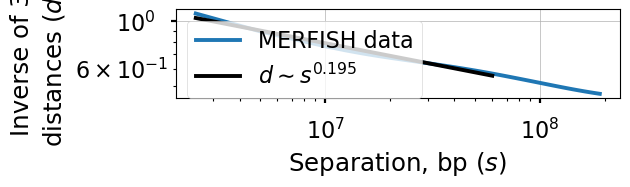



======= MEDIAN =======

v = 0.195
1/v = 5.14
est alpha = B/v = -4.11


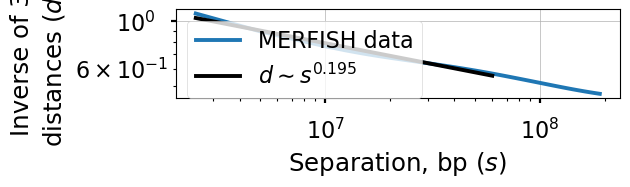

In [25]:
min_n = None
dis_exp = -1; sigma_log10 = 0.1

for agg in ('mean', 'median'):
    print(f"\n\n======= {agg.upper()} =======\n")
    sc_dis_intramol_mean = sc_dis_intramol.median(axis=1).to_frame().rename({0: f'sc_{agg}'}, axis=1)
    s_agg = get_genomic_dist_by_cell(sc_dis_intramol_mean, dis_exp=dis_exp, min_n=min_n)
    s_agg_smooth = smooth_frequency(s_agg, sigma_log10=sigma_log10)
    d, (x, y), est_alpha = estimate_exponent_manual(s_agg_smooth, seed=0, dis_exp=dis_exp, verbose=True)

v = -1.23
1/v = -0.816
est alpha = B/v = 0.653


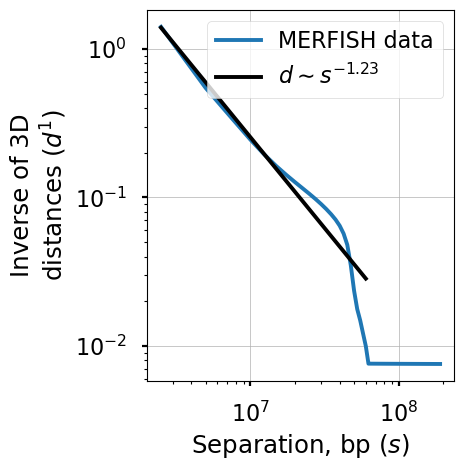

In [28]:
min_n = None
dis_exp = 1; sigma_log10 = 0.1

agg = 'median'  # for agg in ('mean', 'median'):
# print(f"\n\n======= {agg.upper()} =======\n")
sc_dis_intramol_mean = sc_dis_intramol.median(axis=1).to_frame().rename({0: f'sc_{agg}'}, axis=1)
s_agg = get_genomic_dist_by_cell(sc_dis_intramol_mean, dis_exp=dis_exp, min_n=min_n) ** -5
s_agg_smooth = smooth_frequency(s_agg, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(s_agg_smooth, seed=0, dis_exp=dis_exp, verbose=True)

### Get exponent per cell

In [336]:
def get_exponent_per_cell(df, dis_exp):
    genomic_dis = df.index.values
    freq_smooth = df.smoothed_freq.values.ravel()
    
    d = estimate_exponent(genomic_dis, freq_smooth=freq_smooth, verbose=False)
    # d = estimate_exponent(
    #     genomic_dis, freq_smooth=freq_smooth, x0=x0, bounds=bounds, seed=seed,
    #     max_iter=max_iter, verbose=False)

    v = d['exponent'] / dis_exp
    detected_genomic_dis = s = df[df.n > 0].index.values
    res = {
        'v': v, 'n_sum': df.n.sum(), 'detected_sum': df.n.notnull().sum(),
        's_size': int(s.size), 's_mean': s.mean(), 's_median': np.median(s),
        's_range': int(s.max() - s.min() + 1)}
    return pd.Series(res)


min_genomic_dis = None; max_genomic_dis = 'default'

if min_genomic_dis is None:
    min_genomic_dis = s_by_cell_smooth.index.min()
if max_genomic_dis is None:
    max_genomic_dis = s_by_cell_smooth.index.max()
elif isinstance(max_genomic_dis, str) and max_genomic_dis.lower() == 'default':
    max_genomic_dis = 6e7
mask = (s_by_cell_smooth.index <= max_genomic_dis) & (s_by_cell_smooth.index >= min_genomic_dis)

# tmp = s_by_cell_smooth[mask].groupby('cell_num').apply(get_exponent_per_cell, dis_exp=dis_exp, include_groups=False)
# n_sum = s_by_cell_smooth[mask].groupby('cell_num').n.sum().to_frame().rename({'n': 'n_sum'}, axis=1)
# per_cell = pd.concat([n_sum, tmp.to_frame().rename({0: 'v'}, axis=1)], axis=1)

per_cell = s_by_cell_smooth[mask].groupby('cell_num').apply(get_exponent_per_cell, dis_exp=dis_exp, include_groups=False)
for col in [col in per_cell.columns if col != 'v']:  #['n_sum', 's_size', 's_mean', 's_median', 's_range']:
    per_cell[col] = per_cell[col].astype(int)

In [372]:
min_nsum = int(round(per_cell.n_sum.quantile(0.5)))

display(per_cell.describe().round(2))
print('\ns < -0.25')
display(per_cell[per_cell.v < -0.25].describe().round(2))
print(f'\nn_sum > {min_nsum}')
display(per_cell[per_cell.n_sum >= min_nsum].describe().round(2))

pairs_per_cell = s_by_cell_smooth[mask].groupby('cell_num').n.sum()
cells_to_use = pairs_per_cell[pairs_per_cell >= min_nsum].index
num_pairs_orig = sc_dis_intramol.notnull().values.sum()
num_pairs_final = sc_dis_intramol[cells_to_use].notnull().values.sum()
print(f"Retaining {round(num_pairs_final / num_pairs_orig * 100):g}% of pairs")

,v,n_sum,s_size,s_mean,s_median,s_range
count,3702.00,3702.00,3702.00,3702.00,3702.00,3702.00
mean,0.15,2536.00,59.65,30.07,30.07,60.44
std,0.34,2584.42,12.52,6.25,6.25,12.44
min,-2.74,28.00,15.00,9.00,9.00,17.00
25%,0.15,630.00,50.00,25.00,25.00,50.00
50%,0.19,1550.00,60.00,30.00,30.00,61.00
75%,0.23,3629.00,71.00,36.00,36.00,71.00
max,0.66,14663.00,76.00,38.00,38.00,76.00



s < -0.25


,v,n_sum,s_size,s_mean,s_median,s_range
count,53.00,53.00,53.00,53.00,53.00,53.00
mean,-2.44,106.66,23.25,12.08,12.19,24.25
std,0.77,108.89,7.71,3.83,3.85,7.69
min,-2.74,28.00,15.00,9.00,9.00,17.00
25%,-2.74,55.00,20.00,10.00,10.00,21.00
50%,-2.74,78.00,21.00,11.00,11.00,22.00
75%,-2.74,105.00,23.00,12.00,12.00,23.00
max,-0.26,631.00,55.00,28.00,28.00,57.00



n_sum > 1550


,v,n_sum,s_size,s_mean,s_median,s_range
count,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00
mean,0.20,4375.34,67.95,34.22,34.22,68.58
std,0.05,2533.50,7.05,3.52,3.52,7.09
min,-0.08,1550.00,47.00,24.00,24.00,47.00
25%,0.17,2355.00,61.00,31.00,31.00,61.00
50%,0.20,3629.00,70.00,35.00,35.00,71.00
75%,0.23,5704.25,75.00,38.00,38.00,75.00
max,0.40,14663.00,76.00,38.00,38.00,76.00


Retaining 86% of pairs


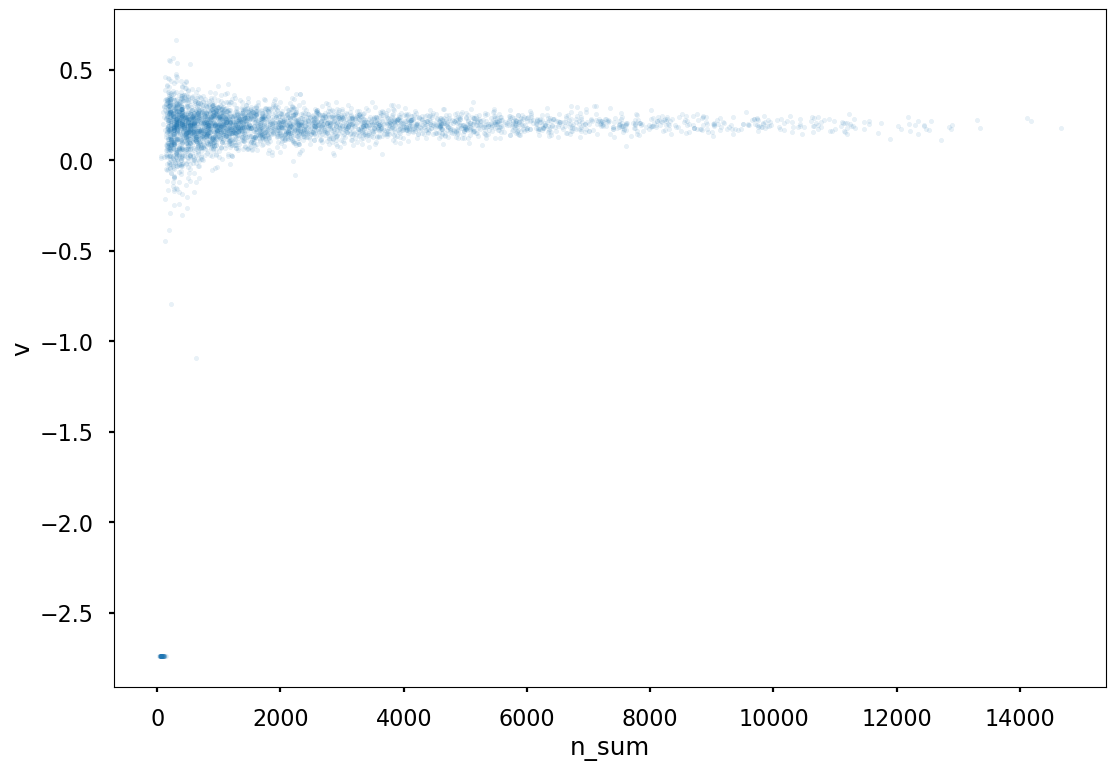

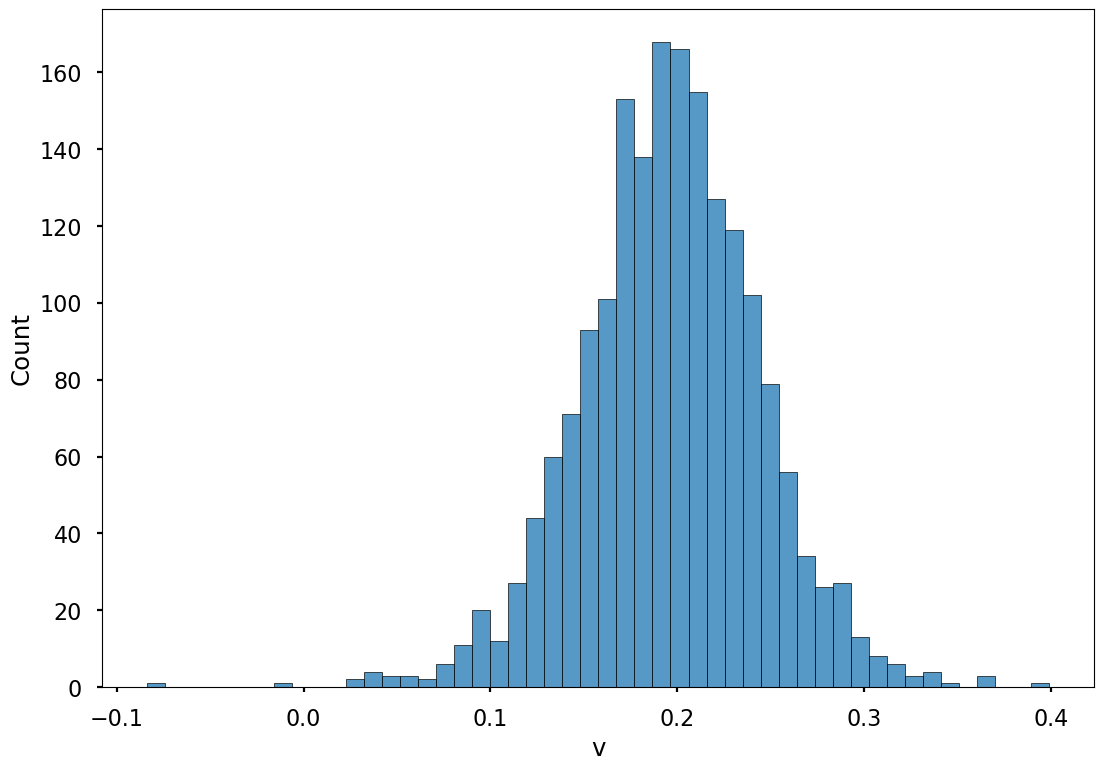

In [367]:
sns.scatterplot(data=per_cell, x="n_sum", y="v", s=10, alpha=0.1, edgecolors=None)  # 
plt.show()

sns.histplot(data=per_cell[per_cell.n_sum > per_cell.n_sum.quantile(0.5)], x="v")
plt.show()

## Plot

v = 0.143
1/v = 7.02
est alpha = B/v = -5.61


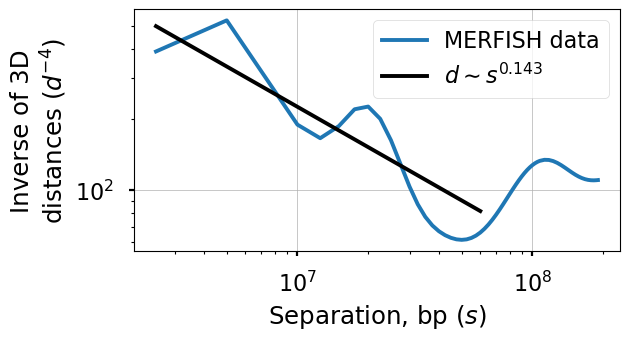

v = 0.143
1/v = 7.02
est alpha = B/v = -5.61


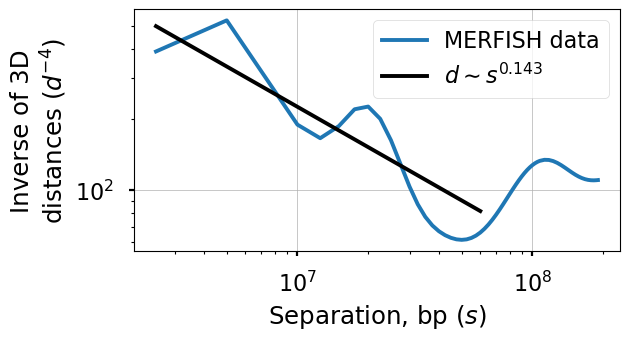

In [93]:
min_nsum = 0


data_smooth = s_smooth
data_orig = s_by_cell
if min_nsum > 1:
    pairs_per_cell = s_smooth[s_smooth.n >= min_nsum].groupby('cell_num').n.sum()
    cells_to_use = pairs_per_cell[pairs_per_cell >= min_nsum].index
    num_pairs_orig = sc_dis_intramol.notnull().values.sum()
    num_pairs_final = sc_dis_intramol[cells_to_use].notnull().values.sum()
    print(f"Retaining {round(num_pairs_final / num_pairs_orig * 100):g}% of pairs\n\n")
    data_smooth = data_smooth[data_smooth.cell_num.isin(cells_to_use)]
    data_orig = data_orig[cells_to_use]
# data_smooth = data_smooth.copy(); data_smooth[data_smooth.n < 40] = np.nan

# s_smooth_mean = data_smooth.groupby(level=0).mean().drop('cell_num', axis=1)
# # display(s_smooth_mean.head(2)); display(s_smooth_mean.tail(2))
# d, (x, y), est_alpha = estimate_exponent_manual(s_smooth_mean, seed=0, dis_exp=dis_exp, verbose=True)

# s_smooth_med = data_smooth.groupby(level=0).median().drop('cell_num', axis=1)
# # display(s_smooth_med.head(2)); display(s_smooth_med.tail(2))
# d, (x, y), est_alpha = estimate_exponent_manual(s_smooth_med, seed=0, dis_exp=dis_exp, verbose=True)

s_by_cell_mean = data_orig.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
s_mean_smooth = smooth_frequency(s_by_cell_mean, sigma_log10=0.1)
# display(s_mean_smooth.head(2)); display(s_mean_smooth.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(s_mean_smooth, seed=0, dis_exp=dis_exp, verbose=True)


s_by_cell_med = data_orig.median(axis=1).to_frame().rename({0: 'sc_median'}, axis=1)
s_med_smooth = smooth_frequency(s_by_cell_mean, sigma_log10=0.1)
# display(s_med_smooth.head(2)); display(s_med_smooth.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(s_med_smooth, seed=0, dis_exp=dis_exp, verbose=True)

# Fxn

In [2]:
n = 11
x_true = np.triu(np.ones((n, n)), 1).sum()
x = (n ** 2 - n) / 2
n_result = int((1 + np.sqrt(1 + 8 * x)) / 2)
print(x_true, x)
print(n, n_result)

55.0 55.0
11 11


In [3]:
def agg_across_genomic_dist(df, min_n=None):
    data_sum = df.sum(axis=0)
    data_sum.name = 'data'
    n_detected_sum = df.notnull().sum(axis=0)
    n_detected_sum.name = 'n'
    if min_n is not None and min_n > 1:
        nan_mask = n_detected_sum < min_n
        data_sum[nan_mask] = 0
        n_detected_sum[nan_mask] = 0
    res = pd.concat([
        data_sum.to_frame().T, n_detected_sum.to_frame().T])
    return res


def get_genomic_dist_by_cell(sc_dis_intramol, min_n=None, dis_exp=-1):
    sc_invdis_intramol = sc_dis_intramol.pow(dis_exp)
    sc_invdis_intramol.index = [j - i for i, j in sc_invdis_intramol.index]
    sc_invdis_intramol.columns.name = 'cell_num'
    sc_invdis_intramol.sort_index(inplace=True)
    s_by_cell = sc_invdis_intramol.groupby(level=0).apply(agg_across_genomic_dist, min_n=min_n)
    s_by_cell.index.names = ['genomic_dis', 'desc']
    return s_by_cell

In [4]:
def smooth_frequency(df_freq, sigma_log10=0.1):
    df_freq_smooth = []
    
    for col in df_freq.columns:
        cell_data = df_freq[col].unstack()
        cell_data.columns.name = None

        mask = cell_data.n > 0
        if sigma_log10 is None or not sigma_log10:
            cell_data['smoothed_data'] = cell_data.data
            cell_data['smoothed_n'] = cell_data.n
        else:
            smoothed_data, smoothed_n = log_smooth(
                cell_data[mask].index.values.astype(np.float64),
                cell_data.loc[mask, ['data', 'n']].values.T,
                sigma_log10=sigma_log10,
                window_sigma=5, points_per_sigma=10)
            cell_data.loc[mask, 'smoothed_data'] = smoothed_data
            cell_data.loc[mask, 'smoothed_n'] = smoothed_n

        cell_data['smoothed_freq'] = np.nan
        mask_sm = mask & cell_data.smoothed_n != 0
        cell_data.loc[mask_sm, 'smoothed_freq'] = cell_data.loc[mask_sm, 'smoothed_data'] / cell_data.loc[mask_sm, 'smoothed_n']
        cell_data['cell_num'] = col
        cell_data['n'] = cell_data['n'].astype(int)
    
        df_freq_smooth.append(cell_data)
    
    df_freq_smooth = pd.concat(df_freq_smooth)
    return df_freq_smooth

In [5]:
def estimate_exponent_manual(s_by_cell_smooth_agg, x0=None, bounds=(-10, 10), seed=0,
                             min_genomic_dis=None, max_genomic_dis='default',
                             max_iter=1e20, resolution_bp=2.5e6, verbose=True, plot=True, dis_exp=-1):

    dist_decay = s_by_cell_smooth_agg.smoothed_freq.copy()
    dist_decay.index *= int(resolution_bp)
    
    # Build args
    if min_genomic_dis is None:
        min_genomic_dis = dist_decay.index.min()
    if max_genomic_dis is None:
        max_genomic_dis = dist_decay.index.max()
    elif isinstance(max_genomic_dis, str) and max_genomic_dis.lower() == 'default':
        max_genomic_dis = 6e7
    mask = (dist_decay.index <= max_genomic_dis) & (dist_decay.index >= min_genomic_dis)
    genomic_dis = dist_decay[mask].index.values
    freq_smooth = dist_decay[mask].values.ravel()

    d = estimate_exponent(
        genomic_dis, freq_smooth=freq_smooth, x0=x0, bounds=bounds, seed=seed,
        max_iter=max_iter, verbose=verbose - 1)

    x = genomic_dis
    y = d['scaling_factor'] * np.power(x, d['exponent'])

    exponent_dis3d = d['exponent'] / dis_exp
    est_alpha = -0.8 / exponent_dis3d
    if verbose:
        if verbose > 1:
            print(flush=True)
        print(f"v = {exponent_dis3d:.3g}")
        print(f"1/v = {1 / exponent_dis3d:.3g}")
        print(f"est alpha = B/v = {est_alpha:.3g}")

    if plot:
        f, ax = plt.subplots(figsize=[6.4, 4.8])
        ax.loglog(
            s_by_cell_smooth_agg.index.values * 2.5e6,
            s_by_cell_smooth_agg.smoothed_freq.values,
            label='MERFISH data')
        ax.set(
            xlabel='Separation, bp ($s$)', 
            ylabel='Inverse of 3D\n' + r'distances $(d^{' + f"{dis_exp:g}" '})$')
        ax.set_aspect(1.0)
        ax.grid(lw=0.5)
        
        ax.loglog(x, y, color='black', label=r"$d \sim s^{" + f"{exponent_dis3d:.3g}" + r"}$")

        # ax.set_ylim()
        ax.set_title(f"")
        plt.legend()
        f.tight_layout()
        plt.show()

    return d, (x, y), est_alpha

In [6]:
import jax.numpy as jnp
from jax import grad
from scipy import optimize
from estimate_alpha import print_alpha_infer_results


def estimate_scaling_factor(exponent, genomic_dis, freq_smooth):
    y = jnp.power(genomic_dis, exponent)
    scaling_factor = jnp.sum(y * freq_smooth) / jnp.sum(jnp.square(y))
    return scaling_factor


def fit_exponent_obj(exponent, genomic_dis, freq_smooth, scaling_factor):
    y = scaling_factor * jnp.power(genomic_dis, exponent)
    mse = jnp.mean(jnp.square(freq_smooth - y))
    return mse


fit_exponent_grad = grad(fit_exponent_obj)


def obj_wrap(exponent, genomic_dis, freq_smooth):
    scaling_factor = estimate_scaling_factor(exponent, genomic_dis=genomic_dis, freq_smooth=freq_smooth)
    obj = fit_exponent_obj(exponent, genomic_dis=genomic_dis, freq_smooth=freq_smooth, scaling_factor=scaling_factor)
    if not isinstance(obj, float) and obj.size > 1:
        obj = sum(obj)
    return obj


def grad_wrap(exponent, genomic_dis, freq_smooth):
    scaling_factor = estimate_scaling_factor(exponent, genomic_dis=genomic_dis, freq_smooth=freq_smooth)
    return np.array(fit_exponent_grad(exponent, genomic_dis=genomic_dis, freq_smooth=freq_smooth, scaling_factor=scaling_factor)).ravel()


def estimate_exponent(genomic_dis, freq_smooth, x0=None, bounds=(-10, 10), seed=0,
                      max_iter=1e20, verbose=True):
    # Define initial value (x0) and bounds on X
    if x0 is None:
        rng = np.random.default_rng(seed=seed)
        x0 = rng.uniform(low=bounds[0], high=bounds[1])
    x0 = np.array(x0, ndmin=1, copy=None)
    bounds = np.array(bounds, ndmin=2, copy=None).reshape(1, -1)

    # Build args
    args = [genomic_dis, freq_smooth]

    # Optimize
    if verbose:
        print("OPTIMIZING:", flush=True)
    obj = obj_wrap(x0, *args)
    if max_iter == 0:
        X = x0
        d = {'converged': 'N/A', 'obj': obj._value}
    else:
        results = optimize.fmin_l_bfgs_b(
            obj_wrap, x0=x0, fprime=grad_wrap, bounds=bounds, args=args,
            factr=1e-20, maxls=40, pgtol=1e-10, maxiter=int(max_iter)) #, maxfun=max_fun)
        X, obj, d = results
        d['converged'] = d['warnflag'] == 0
        conv_desc = d['task']
        d['obj'] = obj
    if X.size == 1:
        d['exponent'] = X[0]
    else:
        d['exponent'] = X
    d['scaling_factor'] = float(estimate_scaling_factor(X, *args)._value)

    if verbose:
        print("\nRESULTS:", flush=True)
        print_alpha_infer_results(d)

    return d

/net/gs/vol1/home/gesine/local/anaconda3/envs/py311/lib/python3.11/site-packages/iced/normalization/_ca_utils.py:8: UserWarning: The API of this module is likely to change. Use only for testing purposes
  warnings.warn(
/net/noble/vol4/noble/user/gesine/repos/pastis/pastis/fastio.py:7: UserWarning: The module pastis.fastio is deprecated. The packaged iced has identical features and should be used instead. This module will be removed in version 0.5
  warnings.warn(
